# **Imports**

In [2]:
import os
import json
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings("ignore")

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print("Using device:", device)

Using device: xpu


# **Paths & Data Load**

In [3]:
BASE_DIR = "../../data"
TRAIN_DIR = os.path.join(BASE_DIR, "train_images")

df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))

with open(os.path.join(BASE_DIR, "label_num_to_disease_map.json")) as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}

df["disease_name"] = df["label"].map(label_map)
num_classes = df["label"].nunique()

print("Total images:", len(df))
print("Number of classes:", num_classes)
df.head()

Total images: 21397
Number of classes: 5


,image_id,label,disease_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


# **Train / Validation / Test Split (Stratified)**

In [4]:
# First split: train (70%) vs temp (30%)
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

# Second split: temp -> validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

# Verify class distribution is preserved
print("\nTrain class distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())

Train size: 14977
Validation size: 3210
Test size: 3210

Train class distribution:
label
0    0.050811
1    0.102290
2    0.111504
3    0.614943
4    0.120451
Name: proportion, dtype: float64


# **Handle Class Imbalance (Class Weights)**

In [5]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Class weights: tensor([3.9361, 1.9552, 1.7937, 0.3252, 1.6604], device='xpu:0')


# **Data Augmentation & Normalization**

In [6]:
IMG_SIZE = 224  # standard input size for most pretrained CNNs

# Training transforms: includes augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                          std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms: no augmentation, only resize + normalize
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# **Custom Dataset Class**

In [7]:
class CassavaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = CassavaDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = CassavaDataset(val_df, TRAIN_DIR, transform=eval_transform)
test_dataset = CassavaDataset(test_df, TRAIN_DIR, transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Batches -> Train:", len(train_loader), "Val:", len(val_loader), "Test:", len(test_loader))

Batches -> Train: 469 Val: 101 Test: 101


# **Helper Functions: Train, Evaluate, Metrics, Param Count**

In [8]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def get_model_size_mb(model):
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / (1024 ** 2)
    return size_mb

def train_one_epoch(model, loader, optimizer, criterion, epoch_num, total_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for this epoch's batches (shows how much of the epoch is done)
    pbar = tqdm(loader, desc=f"Epoch {epoch_num}/{total_epochs} [Train]", leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Live batch-level stats shown on the progress bar itself
        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "running_acc": f"{correct/total:.4f}"
        })

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, desc="Val"):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc=f"[{desc}]", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)

    return avg_loss, acc, f1, precision, recall, per_class_recall, all_preds, all_labels

# **Full Training Loop Function (Reusable for Every Baseline)**

In [ ]:
def plot_final_training_curves(history, model_name):
    """Called ONCE after all epochs finish — shows loss, accuracy, and macro-F1 curves"""
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Loss curve
    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="o")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy curve
    axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
    axes[1].plot(epochs_range, history["val_acc"], label="Val Acc", marker="o")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Macro-F1 curve (primary metric)
    axes[2].plot(epochs_range, history["val_f1"], label="Val Macro-F1", marker="o", color="green")
    axes[2].set_title(f"{model_name} — Macro-F1 (Primary Metric)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro-F1")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{model_name}_training_curves.png", dpi=300, bbox_inches="tight")
    plt.show()


def run_training(model, model_name, num_epochs=5, lr=0.0001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, num_epochs)
        val_loss, val_acc, val_f1, val_prec, val_rec, val_per_class_recall, _, _ = evaluate(model, val_loader, criterion, desc="Validation")

        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        # Simple one-line print after each epoch (no graph yet)
        print(f"[{model_name}] Epoch {epoch}/{num_epochs} ({epoch_time:.1f}s) | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} Macro-F1: {val_f1:.4f}")

    training_time = time.time() - start_time

    # Final test evaluation
    test_loss, test_acc, test_f1, test_prec, test_rec, test_per_class_recall, test_preds, test_labels = evaluate(model, test_loader, criterion, desc="Test")

    total_params, trainable_params = count_parameters(model)
    model_size = get_model_size_mb(model)

    results = {
        "model_name": model_name,
        "test_f1_macro": test_f1,
        "test_recall_macro": test_rec,
        "test_precision_macro": test_prec,
        "test_accuracy": test_acc,
        "test_per_class_recall": test_per_class_recall,
        "training_time_sec": training_time,
        "total_params": total_params,
        "model_size_mb": model_size,
        "history": history,
        "test_preds": test_preds,
        "test_labels": test_labels
    }

    print(f"\n[{model_name}] FINAL TEST -> Macro-F1: {test_f1:.4f} | Macro-Recall: {test_rec:.4f} | "
          f"Accuracy: {test_acc:.4f} | Params: {total_params:,} | "
          f"Size: {model_size:.2f} MB | Time: {training_time:.1f}s\n")

    return model, results

# **Attention Module Definitions (CORE CONTRIBUTION)**

In [10]:
# =========================================================
# CHANNEL ATTENTION MODULE (inspired by Squeeze-and-Excitation)
# Learns "which feature channels matter most" for disease detection
# =========================================================
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(in_channels // reduction_ratio, in_channels)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()

        avg_out = self.mlp(self.avg_pool(x).view(b, c))
        max_out = self.mlp(self.max_pool(x).view(b, c))

        channel_weights = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * channel_weights  # recalibrate channels


# =========================================================
# SPATIAL ATTENTION MODULE
# Learns "WHERE in the image" (which pixels/lesion regions) matter most
# =========================================================
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)

        spatial_weights = self.sigmoid(self.conv(combined))
        return x * spatial_weights  # highlight important regions (e.g. lesions)


# =========================================================
# DUAL ATTENTION BLOCK = Channel Attention + Spatial Attention (sequential, CBAM-style)
# =========================================================
class DualAttentionBlock(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel=7):
        super(DualAttentionBlock, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attention = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = self.channel_attention(x)   # step 1: recalibrate "what" matters
        x = self.spatial_attention(x)   # step 2: recalibrate "where" matters
        return x

# **AttenLeafNet: Full Architecture (Lightweight Backbone + Dual Attention)**

In [11]:
# =========================================================
# AttenLeafNet: Lightweight Dual-Attention CNN
# Backbone: MobileNetV2 (lightweight, pretrained) 
# Attention: Dual Attention Block inserted after backbone's feature extractor,
#            before classification head
# =========================================================
class AttenLeafNet(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(AttenLeafNet, self).__init__()

        # Lightweight pretrained backbone (feature extractor only)
        base_model = models.mobilenet_v2(weights="IMAGENET1K_V1" if pretrained else None)
        self.backbone = base_model.features  # output shape: [B, 1280, H, W]

        backbone_out_channels = 1280

        # Dual Attention Block placed right after the backbone's last conv layer
        self.attention = DualAttentionBlock(in_channels=backbone_out_channels,
                                             reduction_ratio=16, spatial_kernel=7)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(backbone_out_channels, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)          # extract features: [B, 1280, 7, 7]
        x = self.attention(x)         # apply dual attention (channel + spatial)
        x = self.global_pool(x)       # [B, 1280, 1, 1]
        x = torch.flatten(x, 1)       # [B, 1280]
        x = self.classifier(x)        # [B, num_classes]
        return x

    def forward_with_attention_map(self, x):
        """Used later for visualization - returns both output and spatial attention map"""
        features = self.backbone(x)
        channel_refined = self.attention.channel_attention(features)

        avg_out = torch.mean(channel_refined, dim=1, keepdim=True)
        max_out, _ = torch.max(channel_refined, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        attention_map = torch.sigmoid(self.attention.spatial_attention.conv(combined))

        spatial_refined = channel_refined * attention_map
        pooled = self.global_pool(spatial_refined)
        out = self.classifier(torch.flatten(pooled, 1))

        return out, attention_map

# Quick architecture check
model_test = AttenLeafNet(num_classes=num_classes)
sample_input = torch.randn(1, 3, 224, 224)
output = model_test(sample_input)
print("Output shape:", output.shape)  # should be [1, 5]
print(model_test)

Output shape: torch.Size([1, 5])
AttenLeafNet(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1,

# **Train AttenLeafNet**

In [12]:
atten_leaf_net = AttenLeafNet(num_classes=num_classes, pretrained=True)
atten_leaf_net, results_attenleafnet = run_training(atten_leaf_net, "AttenLeafNet", num_epochs=15, lr=0.0001)

Epoch 1/15 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[AttenLeafNet] Epoch 1/15 (190.2s) | Train Loss: 1.0237 Acc: 0.6806 | Val Loss: 0.8556 Acc: 0.7324 Macro-F1: 0.6322


Epoch 2/15 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

...

Epoch 15/15 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[AttenLeafNet] Epoch 15/15 (145.0s) | Train Loss: 0.4454 Acc: 0.8573 | Val Loss: 0.7722 Acc: 0.8065 Macro-F1: 0.6952


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[AttenLeafNet] FINAL TEST -> Macro-F1: 0.7074 | Macro-Recall: 0.7375 | Accuracy: 0.8159 | Params: 2,759,352 | Size: 10.66 MB | Time: 2232.3s



# **Load Baseline Results & Build Final Comparison Table**

In [24]:
with open("../task2/baseline_results.pkl", "rb") as f:
    baseline_results = pickle.load(f)
# adjust the path above based on where File 1 saved this pickle relative to File 2

all_final_results = baseline_results + [results_attenleafnet]

final_summary = pd.DataFrame([{
    "Model": r["model_name"],
    "Test Accuracy": round(r["test_accuracy"], 4),
    "Macro F1": round(r["test_f1_macro"], 4),
    "Macro Precision": round(r["test_precision_macro"], 4),
    "Macro Recall": round(r["test_recall_macro"], 4),
    "Training Time (s)": round(r["training_time_sec"], 1),
    "Total Params": f"{r['total_params']:,}",
    "Model Size (MB)": round(r["model_size_mb"], 2)
} for r in all_final_results])

print(final_summary.to_string(index=False))
final_summary.to_csv("final_comparison_all_models.csv", index=False)

          Model  Test Accuracy  Macro F1  Macro Precision  Macro Recall  Training Time (s) Total Params  Model Size (MB)
      SimpleCNN         0.5081    0.4046           0.4016        0.4901              713.1      390,661             1.49
    MobileNetV2         0.7776    0.6821           0.6550        0.7341              816.7    2,230,277             8.64
       ResNet50         0.7657    0.6676           0.6383        0.7320             1028.9   23,518,277            89.92
EfficientNet-B0         0.8065    0.7100           0.6806        0.7534              852.2    4,013,953            15.47
   AttenLeafNet         0.8159    0.7074           0.6873        0.7375             2232.3    2,759,352            10.66


# **"Does Attention Help?" — Direct Comparison Plot**

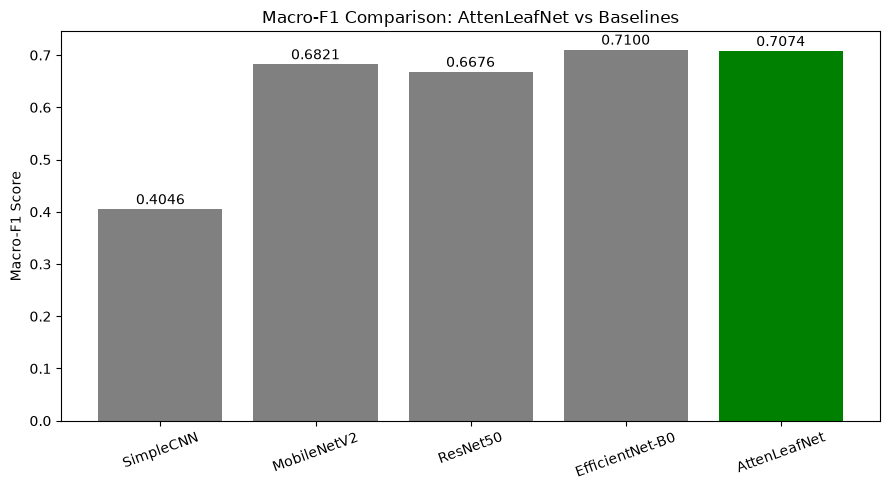

In [25]:
compare_names = [r["model_name"] for r in all_final_results]
compare_f1 = [r["test_f1_macro"] for r in all_final_results]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["green" if name == "AttenLeafNet" else "gray" for name in compare_names]
bars = ax.bar(compare_names, compare_f1, color=colors)

for bar, val in zip(bars, compare_f1):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.4f}", ha="center")

ax.set_title("Macro-F1 Comparison: AttenLeafNet vs Baselines")
ax.set_ylabel("Macro-F1 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("attenleafnet_vs_baselines_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# **Classification Report + Confusion Matrix for AttenLeafNet**

===== Classification Report: AttenLeafNet =====
              precision    recall  f1-score   support

         CBB     0.4688    0.6442    0.5426       163
        CBSD     0.7525    0.6930    0.7215       329
         CGM     0.6541    0.7765    0.7101       358
         CMD     0.9598    0.8820    0.9192      1974
     Healthy     0.6014    0.6917    0.6434       386

    accuracy                         0.8159      3210
   macro avg     0.6873    0.7375    0.7074      3210
weighted avg     0.8364    0.8159    0.8233      3210



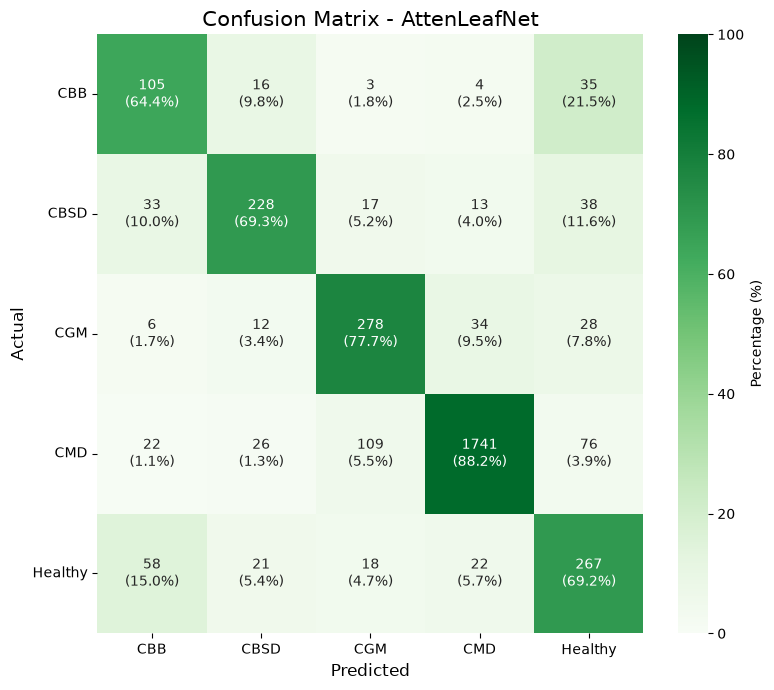

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


short_class_names = [
    "CBB",
    "CBSD",
    "CGM",
    "CMD",
    "Healthy"
]

print("===== Classification Report: AttenLeafNet =====")

print(
    classification_report(
        results_attenleafnet["test_labels"],
        results_attenleafnet["test_preds"],
        target_names=short_class_names,
        digits=4
    )
)


cm = confusion_matrix(
    results_attenleafnet["test_labels"],
    results_attenleafnet["test_preds"]
)

cm_percentage = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
) * 100


annotations = np.empty_like(cm).astype(object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = (
            f"{cm[i, j]}\n"
            f"({cm_percentage[i, j]:.1f}%)"
        )


plt.figure(figsize=(8, 7))

sns.heatmap(
    cm_percentage,
    annot=annotations,
    fmt="",
    cmap="Greens",
    xticklabels=short_class_names,
    yticklabels=short_class_names,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Percentage (%)"},
    annot_kws={"size": 10}
)

plt.title(
    "Confusion Matrix - AttenLeafNet",
    fontsize=15
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "attenleafnet_confusion_matrix_count_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Attention Map Visualization**

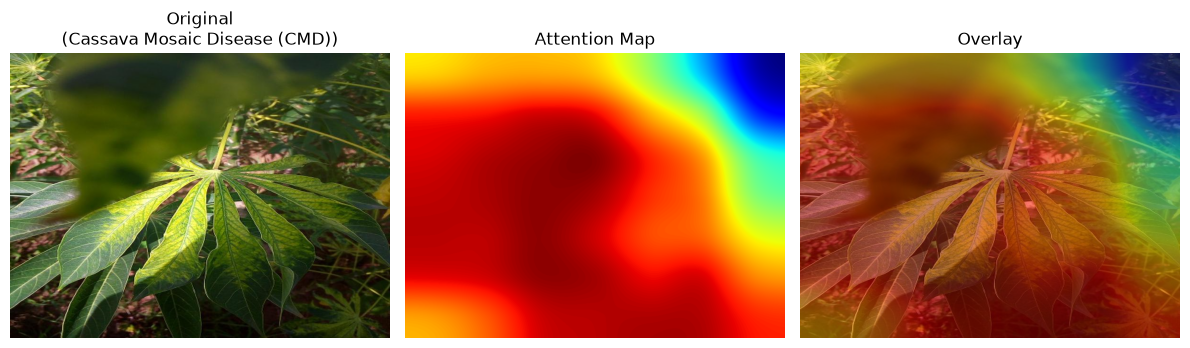

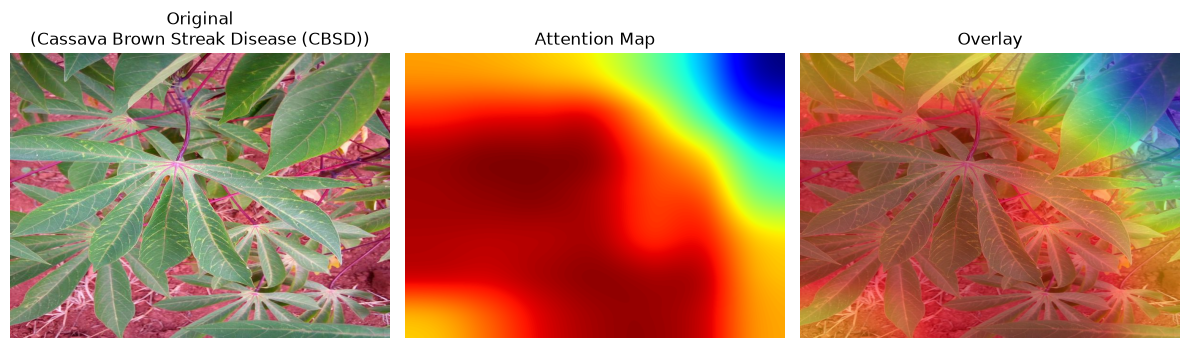

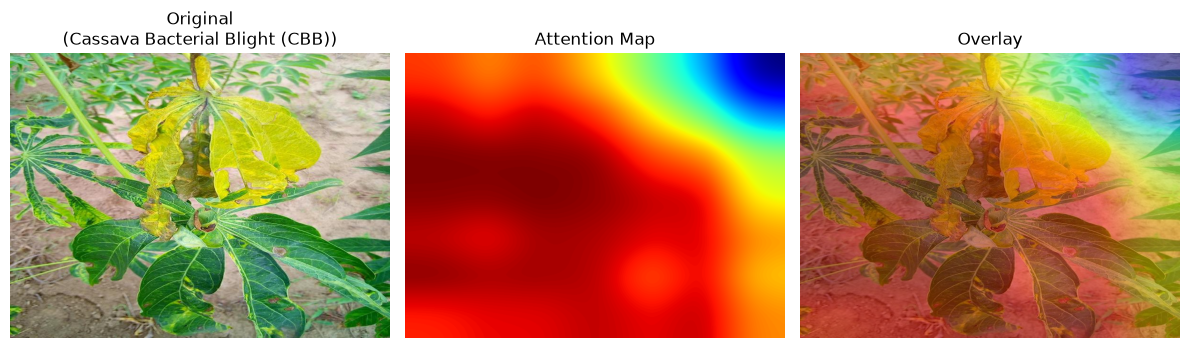

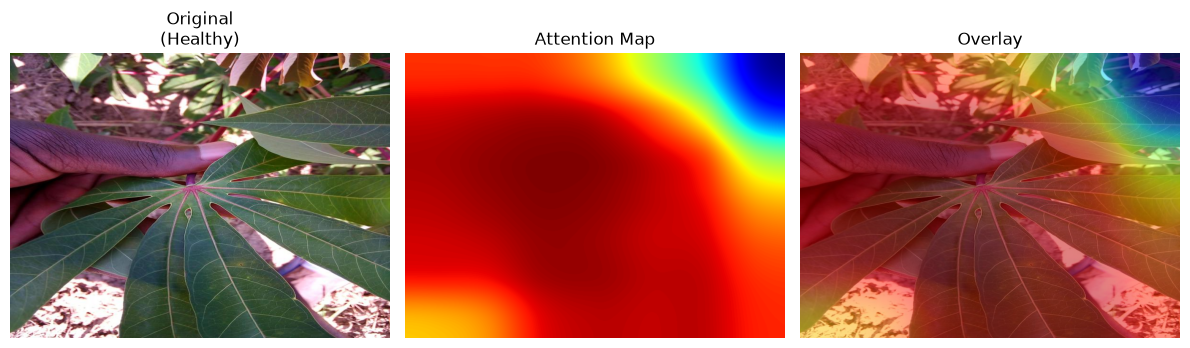

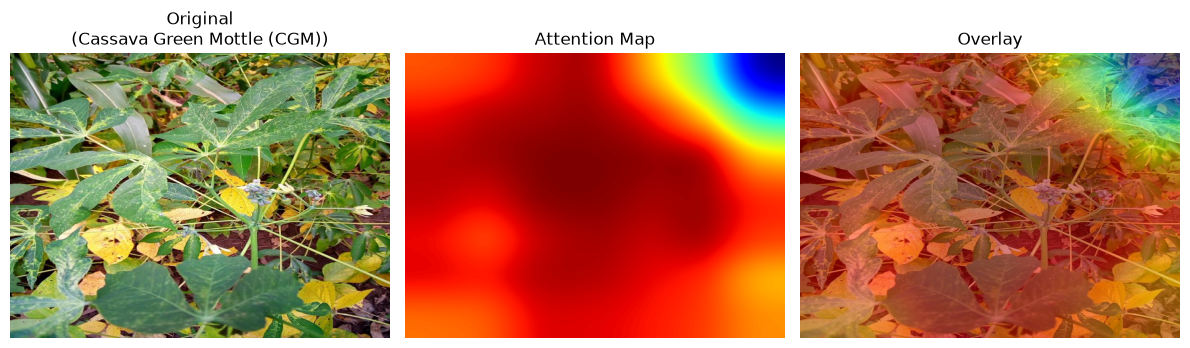

In [19]:
def visualize_attention(model, image_tensor, original_image, class_name, save_path=None):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        output, attention_map = model.forward_with_attention_map(image_tensor)

    attention_map = attention_map.squeeze().cpu().numpy()
    attention_map_resized = np.array(Image.fromarray(attention_map).resize(original_image.size))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original_image)
    axes[0].set_title(f"Original\n({class_name})")
    axes[0].axis("off")

    axes[1].imshow(attention_map_resized, cmap="jet")
    axes[1].set_title("Attention Map")
    axes[1].axis("off")

    axes[2].imshow(original_image)
    axes[2].imshow(attention_map_resized, cmap="jet", alpha=0.5)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Visualize attention for a few test images (one per class)
sample_shown = set()
for idx in range(len(test_df)):
    row = test_df.iloc[idx]
    if row["label"] not in sample_shown:
        img_path = os.path.join(TRAIN_DIR, row["image_id"])
        original_image = Image.open(img_path).convert("RGB")
        image_tensor = eval_transform(original_image)

        visualize_attention(atten_leaf_net, image_tensor, original_image,
                             label_map[row["label"]],
                             save_path=f"attention_map_class_{row['label']}.png")
        sample_shown.add(row["label"])

    if len(sample_shown) == num_classes:
        break

# **Save Final Trained Model**

In [20]:
torch.save(atten_leaf_net.state_dict(), "attenleafnet_final.pth")
print("Model saved: attenleafnet_final.pth")

Model saved: attenleafnet_final.pth
